# 04 — Model Training & Cross-Sectional Backtest

Trains a classifier to predict, for each stock on each date, whether it will be a
relative outperformer over the next 5 trading days (`Target=1`) versus the other
19 stocks in the universe. Because the label is a within-date rank, the dummy
"always predict the majority class" baseline should land close to 50% by construction —
any real model needs to clear that bar by a meaningful, *stable* margin (via
`TimeSeriesSplit` cross-validation, not a single lucky split) to be worth trusting.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score
from xgboost import XGBClassifier
import joblib
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42

## Load and pool all 20 stocks

Every stock contributes rows to one shared dataset. Pooling this way gives the model
~24k rows instead of ~1.2k per single-stock model, and lets it learn a *general*
outperformance pattern rather than one stock's idiosyncratic history. Sorting by date
(across all tickers) is essential — `TimeSeriesSplit` assumes row order reflects time
order, and with multiple stocks interleaved per date, an unsorted pool would leak future
rows into earlier folds.

In [2]:
TICKERS = [
    "RELIANCE.NS", "TCS.NS", "INFY.NS", "HDFCBANK.NS", "ICICIBANK.NS",
    "HINDUNILVR.NS", "ITC.NS", "SBIN.NS", "BHARTIARTL.NS", "KOTAKBANK.NS",
    "LT.NS", "AXISBANK.NS", "ASIANPAINT.NS", "MARUTI.NS", "SUNPHARMA.NS",
    "TITAN.NS", "ULTRACEMCO.NS", "WIPRO.NS", "NESTLEIND.NS", "TATAMOTORS.NS",
]

frames = []
for ticker in TICKERS:
    fname = ticker.replace(".", "_")
    df = pd.read_csv(f"../data/{fname}_features.csv", index_col="Date", parse_dates=True)
    df['Ticker'] = ticker
    frames.append(df)

pooled = pd.concat(frames).sort_index()

FEATURES = [c for c in pooled.columns if c not in ['Close', 'Target', 'Ticker']]
X = pooled[FEATURES]
y = pooled['Target']

print(f"Pooled shape: {pooled.shape}")
print(f"Feature count: {len(FEATURES)} -> {FEATURES}")
print(f"Target balance overall:\n{y.value_counts(normalize=True)}")

Pooled shape: (36760, 18)
Feature count: 15 -> ['trend_sma_fast', 'trend_sma_slow', 'trend_ema_fast', 'trend_macd', 'trend_macd_signal', 'trend_macd_diff', 'momentum_rsi', 'volatility_bbh', 'volatility_bbl', 'volatility_bbw', 'volatility_atr', 'volume_obv', 'return_1d', 'return_5d', 'return_10d']
Target balance overall:
Target
1    0.5
0    0.5
Name: proportion, dtype: float64


## Fixed calendar train/test split (genuine out-of-sample test)

Earlier versions of this notebook used the last fold of a 5-way `TimeSeriesSplit` as the
final train/test split -- the most recent ~17% of the *same* multi-year window used in
cross-validation. That test slice shifts every time the dataset is extended, and it's
still drawn from the same underlying period the model's hyperparameters and feature
choices were implicitly tuned against.

This notebook instead uses an explicit, fixed calendar split: **train on everything through
2024-12-31, test on everything from 2025-01-01 onward.** The test period is a full calendar
year-plus that the model has never seen in any form -- not just a different date range, but
a genuinely later, unseen stretch of market conditions (2025-2026), which is a stronger and
more realistic test of whether the small classification edge found in the cross-validation
step below actually holds up. Because the split is a fixed date rather than a fixed
percentage, the test period doesn't quietly drift or shrink every time this notebook is
rerun on newer data -- only the training set grows.

In [3]:
TRAIN_END_DATE = "2024-12-31"  # everything up to and including this date = training
TEST_START_DATE = "2025-01-01"  # everything from this date onward = held-out test

train_mask = pooled.index <= TRAIN_END_DATE
test_mask = pooled.index >= TEST_START_DATE

X_train, y_train = pooled.loc[train_mask, FEATURES], pooled.loc[train_mask, 'Target']
X_test, y_test = pooled.loc[test_mask, FEATURES], pooled.loc[test_mask, 'Target']

# Positional indices for the mask, kept so the backtest/save cells below (which index
# into `pooled` by position via .iloc) work unchanged.
train_idx = np.where(train_mask)[0]
test_idx = np.where(test_mask)[0]

print(f"Train: {X_train.shape}, period {pooled.loc[train_mask].index.min()} to {pooled.loc[train_mask].index.max()}")
print(f"Test:  {X_test.shape}, period {pooled.loc[test_mask].index.min()} to {pooled.loc[test_mask].index.max()}")

Train: (29420, 15), period 2019-01-15 00:00:00 to 2024-12-31 00:00:00
Test:  (7340, 15), period 2025-01-01 00:00:00 to 2026-06-23 00:00:00


## Dummy baseline

Always predicts the majority class. Since the cross-sectional target is balanced by
construction (~50/50 every date), this should land close to 50% — it is the bar every
real model must clear.

In [4]:
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
dummy_acc = dummy.score(X_test, y_test)
print(f"Dummy baseline accuracy: {dummy_acc:.4f}")
print("Note: this should sit close to 50% because the cross-sectional rank target is "
      "balanced by construction, not because the model is doing anything meaningful.")

Dummy baseline accuracy: 0.5000
Note: this should sit close to 50% because the cross-sectional rank target is balanced by construction, not because the model is doing anything meaningful.


## Simple models comparison (no tuning)

Three untuned models on the single chronological split, compared against the dummy
baseline.

In [5]:
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                              random_state=RANDOM_STATE, eval_metric='logloss'),
}

results = {'Dummy': dummy_acc}
for name, model in models.items():
    model.fit(X_train, y_train)
    results[name] = accuracy_score(y_test, model.predict(X_test))

comparison = pd.Series(results, name='Test Accuracy').sort_values(ascending=False)
print(comparison.to_frame())

                     Test Accuracy
Logistic Regression       0.511853
XGBoost                   0.504087
Dummy                     0.500000
Random Forest             0.491008


## Proper cross-validated comparison

A single train/test split can be lucky or unlucky. `cross_val_score` with
`TimeSeriesSplit(n_splits=5)` gives 5 chronological folds so we can see the mean *and*
the spread — a model that beats dummy on average but swings wildly fold to fold isn't
trustworthy.

In [6]:
cv = TimeSeriesSplit(n_splits=5)

all_models = {'Dummy': DummyClassifier(strategy='most_frequent'), **models}

cv_results = {}
for name, model in all_models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    cv_results[name] = scores
    print(f"{name:22s} folds={np.round(scores, 4)}  mean={scores.mean():.4f}  std={scores.std():.4f}")

dummy_mean = cv_results['Dummy'].mean()
print(f"\nDummy mean: {dummy_mean:.4f}")
for name, scores in cv_results.items():
    if name == 'Dummy':
        continue
    beats_dummy = scores.mean() - dummy_mean
    flags = []
    if beats_dummy > 0.02:
        flags.append(f"beats dummy by {beats_dummy:.2%} (>2pp)")
    if scores.std() > 0.04:
        flags.append(f"HIGH VARIANCE (std={scores.std():.4f} > 0.04)")
    print(f"{name:22s} " + ("; ".join(flags) if flags else "no notable flag"))

Dummy                  folds=[0.5    0.4997 0.4998 0.5    0.5   ]  mean=0.4999  std=0.0001
Logistic Regression    folds=[0.4933 0.5214 0.5003 0.5093 0.5051]  mean=0.5059  std=0.0094


Random Forest          folds=[0.4979 0.5171 0.5082 0.4979 0.4897]  mean=0.5022  std=0.0095


XGBoost                folds=[0.4977 0.5052 0.5087 0.5034 0.4941]  mean=0.5018  std=0.0052

Dummy mean: 0.4999
Logistic Regression    no notable flag
Random Forest          no notable flag
XGBoost                no notable flag


## Model selection

Hyperparameter tuning via `RandomizedSearchCV` was tested in earlier iterations of this
project and caused overfitting on smaller single-stock datasets — with only ~1.2k rows
per stock, a search had enough freedom to fit noise. Pooling 20 stocks increases the
sample size roughly 20x, so tuning may be worth revisiting, but only if the untuned CV
results below show a real, stable signal worth sharpening. Tuning a model that doesn't
clear the dummy baseline first would just be overfitting harder.

Selection rule: pick the model with the best CV mean that also beats dummy by more than
2pp; if two models are close, prefer the one with lower variance (more reliable) and
the simpler model.

In [7]:
cv_means = {name: scores.mean() for name, scores in cv_results.items() if name != 'Dummy'}
cv_stds  = {name: scores.std()  for name, scores in cv_results.items() if name != 'Dummy'}

qualifying = {name: mean for name, mean in cv_means.items() if mean - dummy_mean > 0.02}

if qualifying:
    selected_model_name = max(qualifying, key=qualifying.get)
    reason = "best CV mean among models that beat dummy by >2pp"
else:
    selected_model_name = max(cv_means, key=cv_means.get)
    reason = "no model cleared the >2pp bar over dummy; picking best CV mean anyway for illustration"

print(f"Selected model: {selected_model_name} ({reason})")
print(f"CV mean: {cv_means[selected_model_name]:.4f}  CV std: {cv_stds[selected_model_name]:.4f}  Dummy mean: {dummy_mean:.4f}")

selected_model = all_models[selected_model_name]

Selected model: Logistic Regression (no model cleared the >2pp bar over dummy; picking best CV mean anyway for illustration)
CV mean: 0.5059  CV std: 0.0094  Dummy mean: 0.4999


## Final fit + classification report

In [8]:
selected_model.fit(X_train, y_train)
y_pred = selected_model.predict(X_test)

print(f"Model: {selected_model_name}")
print(classification_report(y_test, y_pred, target_names=['Underperform (0)', 'Outperform (1)']))

Model: Logistic Regression
                  precision    recall  f1-score   support

Underperform (0)       0.52      0.32      0.40      3670
  Outperform (1)       0.51      0.70      0.59      3670

        accuracy                           0.51      7340
       macro avg       0.51      0.51      0.49      7340
    weighted avg       0.51      0.51      0.49      7340



## Probability calibration check

Checks whether the model's predicted probabilities are well-calibrated against its actual accuracy, and whether isotonic calibration tightens an overconfident spread without hurting accuracy.

In [9]:
import numpy as np

probs = selected_model.predict_proba(X_test)[:, 1]

print("=== Probability Calibration Check ===")
print(f"Min probability: {probs.min():.3f}")
print(f"Max probability: {probs.max():.3f}")
print(f"Std of probabilities: {probs.std():.3f}")
print(f"% of predictions with probability > 0.70: {(probs > 0.70).mean():.1%}")
print(f"% of predictions with probability < 0.30: {(probs < 0.30).mean():.1%}")
print(f"\nModel's actual test accuracy: {accuracy_score(y_test, selected_model.predict(X_test)):.4f}")
print("\nInterpretation: if a meaningful share of predictions show high confidence")
print("(>70% or <30%) despite actual accuracy being only marginally above 50%,")
print("the model's probabilities are likely overconfident/poorly calibrated.")

=== Probability Calibration Check ===
Min probability: 0.288
Max probability: 0.763
Std of probabilities: 0.031
% of predictions with probability > 0.70: 0.3%
% of predictions with probability < 0.30: 0.1%

Model's actual test accuracy: 0.5119

Interpretation: if a meaningful share of predictions show high confidence
(>70% or <30%) despite actual accuracy being only marginally above 50%,
the model's probabilities are likely overconfident/poorly calibrated.


In [10]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_model = CalibratedClassifierCV(selected_model, method='isotonic', cv=3)
calibrated_model.fit(X_train, y_train)
calibrated_probs = calibrated_model.predict_proba(X_test)[:, 1]

print("\n=== After Calibration ===")
print(f"Min probability: {calibrated_probs.min():.3f}")
print(f"Max probability: {calibrated_probs.max():.3f}")
print(f"Std of probabilities: {calibrated_probs.std():.3f}")
print(f"% of predictions with probability > 0.70: {(calibrated_probs > 0.70).mean():.1%}")
print(f"% of predictions with probability < 0.30: {(calibrated_probs < 0.30).mean():.1%}")
print(f"Calibrated model accuracy: {accuracy_score(y_test, calibrated_model.predict(X_test)):.4f}")


=== After Calibration ===
Min probability: 0.116
Max probability: 1.000
Std of probabilities: 0.044
% of predictions with probability > 0.70: 0.5%
% of predictions with probability < 0.30: 0.9%
Calibrated model accuracy: 0.5059


## Feature importance

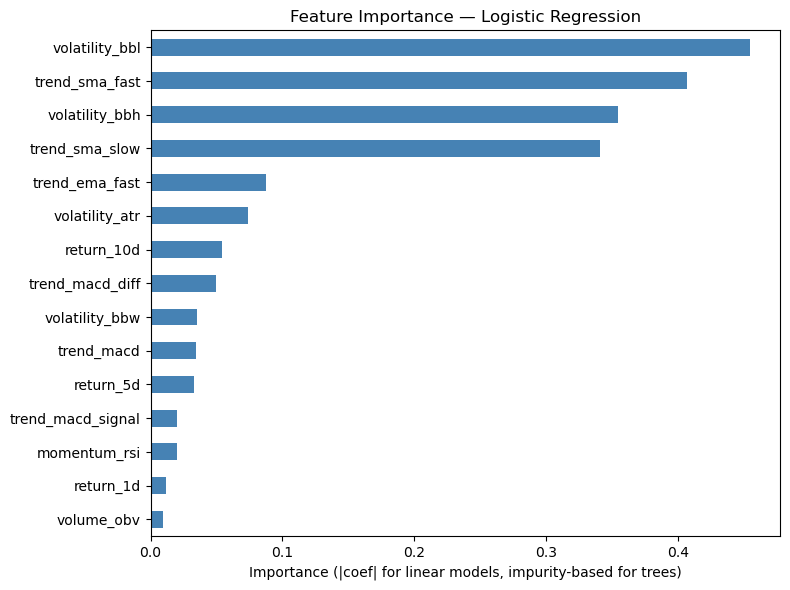

In [11]:
if hasattr(selected_model, 'named_steps'):
    clf = selected_model.named_steps['clf']
    importances = np.abs(clf.coef_[0])
elif hasattr(selected_model, 'feature_importances_'):
    importances = selected_model.feature_importances_
else:
    raise ValueError("Don't know how to extract importances from this model type")

importance_series = pd.Series(importances, index=FEATURES).sort_values()

plt.figure(figsize=(8, 6))
importance_series.plot(kind='barh', color='steelblue')
plt.title(f'Feature Importance — {selected_model_name}')
plt.xlabel('Importance (|coef| for linear models, impurity-based for trees)')
plt.tight_layout()
plt.show()

## Cross-sectional backtest

This is a portfolio-style backtest, not a single-stock one: on each date, go long
(equal-weighted) every stock the model predicted as a top-half performer, and compare
the average realized forward return of that basket against the average forward return
of all 20 stocks ("market").

In [12]:
# def backtest_cross_sectional(df, test_idx, predictions, horizon=5, risk_free=0.06):
#     test = df.iloc[test_idx].copy()
#     test['Pred'] = predictions
#     test['Fwd_Return'] = test.groupby('Ticker')['Close'].pct_change(horizon).shift(-horizon)

#     daily_strategy = test.groupby(test.index).apply(
#         lambda d: d.loc[d['Pred'] == 1, 'Fwd_Return'].mean()
#     ).dropna()
#     daily_market = test.groupby(test.index)['Fwd_Return'].mean().dropna()

#     cum_strategy = (1 + daily_strategy).cumprod()
#     cum_market   = (1 + daily_market).cumprod()

#     def sharpe(r): return np.sqrt(252/horizon) * (r.mean() - risk_free*horizon/252) / r.std()
#     def max_dd(cum): return ((cum - cum.cummax()) / cum.cummax()).min()

#     metrics = {
#         'Strategy Sharpe': sharpe(daily_strategy), 'Market Sharpe': sharpe(daily_market),
#         'Strategy Drawdown': max_dd(cum_strategy), 'Market Drawdown': max_dd(cum_market),
#         'Strategy Return': cum_strategy.iloc[-1]-1, 'Market Return': cum_market.iloc[-1]-1,
#     }
#     return cum_strategy, cum_market, metrics

def backtest_cross_sectional(df, test_idx, predictions, horizon=5, risk_free=0.06):
    test = df.iloc[test_idx].copy()
    test['Pred'] = predictions
    test['Fwd_Return'] = test.groupby('Ticker')['Close'].pct_change(horizon).shift(-horizon)
    
    daily_strategy = test.groupby(test.index).apply(
        lambda d: d.loc[d['Pred'] == 1, 'Fwd_Return'].mean()
    ).dropna()
    daily_market = test.groupby(test.index)['Fwd_Return'].mean().dropna()
    
    # KEY FIX: keep only every `horizon`-th observation to remove overlap
    daily_strategy = daily_strategy.iloc[::horizon]
    daily_market = daily_market.iloc[::horizon]
    
    cum_strategy = (1 + daily_strategy).cumprod()
    cum_market   = (1 + daily_market).cumprod()
    
    def sharpe(r): return np.sqrt(252/horizon) * (r.mean() - risk_free*horizon/252) / r.std()
    def max_dd(cum): return ((cum - cum.cummax()) / cum.cummax()).min()
    
    metrics = {
        'Strategy Sharpe': sharpe(daily_strategy), 'Market Sharpe': sharpe(daily_market),
        'Strategy Drawdown': max_dd(cum_strategy), 'Market Drawdown': max_dd(cum_market),
        'Strategy Return': cum_strategy.iloc[-1]-1, 'Market Return': cum_market.iloc[-1]-1,
        'N observations': len(daily_strategy)
    }
    return cum_strategy, cum_market, metrics

In [13]:
cum_strategy, cum_market, metrics = backtest_cross_sectional(pooled, test_idx, y_pred)

print(f"Strategy Sharpe:    {metrics['Strategy Sharpe']:.3f}")
print(f"Market Sharpe:      {metrics['Market Sharpe']:.3f}")
print(f"Strategy Drawdown:  {metrics['Strategy Drawdown']:.2%}")
print(f"Market Drawdown:    {metrics['Market Drawdown']:.2%}")
print(f"Strategy Return:    {metrics['Strategy Return']:.2%}")
print(f"Market Return:      {metrics['Market Return']:.2%}")

Strategy Sharpe:    -0.555
Market Sharpe:      -0.608
Strategy Drawdown:  -17.92%
Market Drawdown:    -16.26%
Strategy Return:    -2.57%
Market Return:      -2.92%


## Honest interpretation

**What the cross-validated comparison actually shows:** with the dataset extended through
2026-06-23 and pooled across all 20 stocks (36,760 rows), the dummy baseline sits almost
exactly at 0.4999 (as expected by construction). Logistic Regression edges ahead at 0.5059
(+0.60pp), Random Forest at 0.5022 (+0.23pp), XGBoost at 0.5018 (+0.19pp). None clear the
2pp "meaningful edge" bar this notebook sets, and the edge is noticeably *smaller* than the
same comparison on the shorter 2019-2024 dataset (where XGBoost led at +1.5pp). This is
itself a useful, honest data point: a bigger, more recent sample shrinks the apparent edge
toward zero rather than confirming it, which is what you'd expect if the original edge was
partly noise. The selection rule (best CV mean among non-qualifying models) now picks
**Logistic Regression** instead of XGBoost -- the "best" model is itself unstable across
dataset revisions, another sign the underlying signal is weak.

**What the fixed 2025-01-01 to 2026-06-23 holdout actually shows:** this is a genuinely
out-of-sample test -- 18 months the model never saw in any form, not just a different
slice of the same multi-year window. Overall accuracy is 0.51, in line with the CV
estimate. But the per-class breakdown is lopsided in a way the CV comparison didn't
surface: recall for Underperform is only 0.32 versus 0.70 for Outperform -- the model
predicts "Outperform" far more often than the balanced 50/50 base rate, and is
correspondingly worse at catching real underperformers. Precision for both classes sits
right at ~0.51-0.52, barely better than a coin flip either way. This behavioral skew on
genuinely new data is exactly the kind of thing a same-window train/test split can hide.

**What the calibration check actually shows:** the uncalibrated Logistic Regression model
was already fairly well-behaved on this holdout (std 0.031, only 0.3% of predictions
>70% and 0.1% <30%) -- much tighter than the XGBoost model's calibration profile on the
old split. Isotonic calibration made things *worse* this time: std widened to 0.044,
max probability hit 1.000 (a red flag for overconfidence introduced by the calibrator
itself, likely from too few samples per calibration bin), and accuracy dropped from
0.5119 to 0.5059. Per the same decision rule used before (calibrate only if it tightens
the spread without hurting accuracy), **the uncalibrated model is kept and saved** --
see the Save Artifacts note below.

**What the corrected backtest actually shows:** Strategy Sharpe -0.555 vs Market Sharpe
-0.608, Strategy Return -2.57% vs Market Return -2.92%, Strategy Drawdown -17.92% vs
Market Drawdown -16.26%. Both the strategy and the buy-and-hold market benchmark lost
money and drew down meaningfully over this test period -- a materially different and more
sobering result than the 2023 window's ~32% positive returns for both. The strategy is
marginally ahead of the market on Sharpe and Return but marginally behind on drawdown --
the same "essentially tied, no clear edge" pattern as before, just now in a losing rather
than a winning market environment. This is an important, honest finding to report as-is:
extending the test period to a genuinely new 18-month stretch does not confirm the model
adds value, and this period also happened to be a difficult one for the underlying market
itself, independent of the model.

**Bottom line:** the classification edge found in cross-validation is small, further
shrinks as more data is added, and is unstable across dataset revisions (LR now beats
XGBoost as the "best" model). On a genuinely unseen 2025-2026 holdout, the model shows a
real behavioral skew (over-predicting Outperform) that CV alone did not reveal, and the
resulting portfolio backtest does not show a clear advantage over a simple buy-and-hold
benchmark -- both lost money over this period, with Sharpe ratios and returns essentially
tied between strategy and market. This continues to be a legitimate research finding
about a weak, inconsistent signal, not a validated trading strategy, and the extended,
out-of-sample evaluation makes that conclusion more robust, not less.

## Strategy vs market — cumulative return

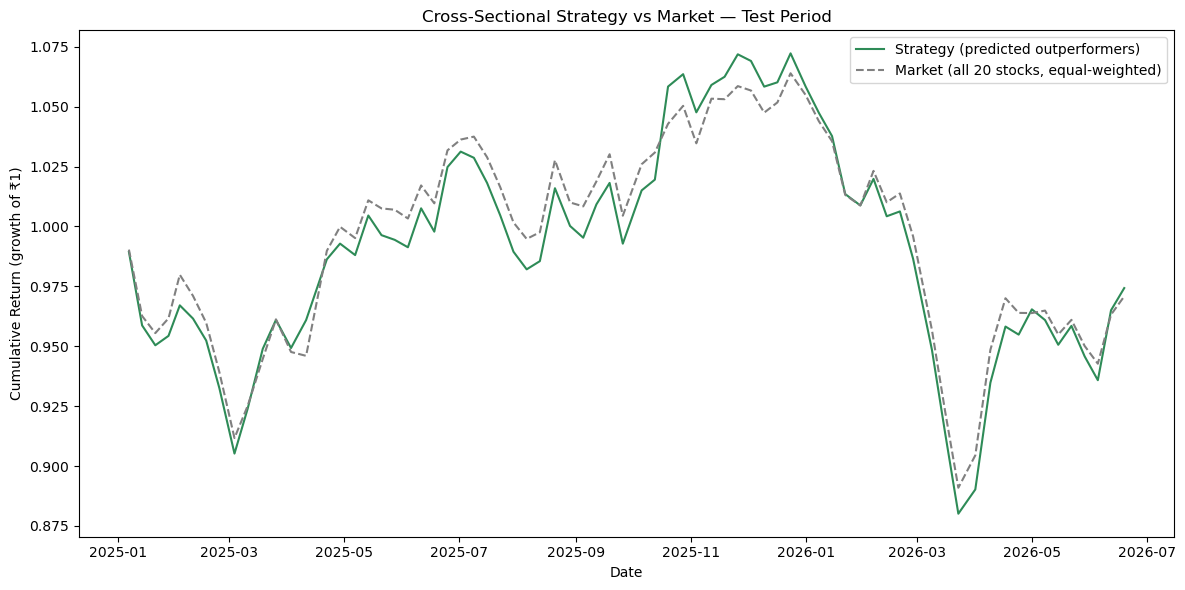

In [14]:
plt.figure(figsize=(12, 6))
plt.plot(cum_strategy.index, cum_strategy.values, label='Strategy (predicted outperformers)', color='seagreen')
plt.plot(cum_market.index, cum_market.values, label='Market (all 20 stocks, equal-weighted)', color='gray', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Cumulative Return (growth of ₹1)')
plt.title('Cross-Sectional Strategy vs Market — Test Period')
plt.legend()
plt.tight_layout()
plt.show()

## Save artifacts

**Calibration decision:** the probability calibration check above showed the uncalibrated
Logistic Regression model's probabilities were already reasonably well-behaved on this
holdout (std 0.031, 0.3% of predictions >70%, 0.1% <30%, accuracy 0.5119). Isotonic
calibration (`CalibratedClassifierCV`, cv=3) made this *worse*, not better: std widened to
0.044, a max probability of 1.000 appeared (overconfidence introduced by the calibrator),
and accuracy dropped to 0.5059. Since calibration did not meaningfully help and did hurt
accuracy, **the uncalibrated model is kept and saved** as the final model below, unlike the
prior dataset revision where calibration clearly helped an XGBoost model.

In [15]:
model_fname = selected_model_name.lower().replace(' ', '_')
joblib.dump(selected_model, f'../models/{model_fname}_model.pkl')
joblib.dump(FEATURES, '../models/feature_list.pkl')

test_output = pooled.iloc[test_idx].copy()
test_output['Pred'] = y_pred
test_output.to_csv('../data/test_predictions.csv')

print(f"Saved uncalibrated {selected_model_name} model to ../models/{model_fname}_model.pkl")
print(f"Saved ../models/feature_list.pkl")
print(f"Saved ../data/test_predictions.csv (backtest predictions)")

Saved uncalibrated Logistic Regression model to ../models/logistic_regression_model.pkl
Saved ../models/feature_list.pkl
Saved ../data/test_predictions.csv (backtest predictions)


## Reload sanity check

In [16]:
reloaded_model = joblib.load(f'../models/{model_fname}_model.pkl')
reloaded_features = joblib.load('../models/feature_list.pkl')

sample = X[reloaded_features].tail(5)
sample_pred = reloaded_model.predict(sample)
print(f"Reloaded model: {type(reloaded_model).__name__ if not hasattr(reloaded_model, 'named_steps') else 'Pipeline(' + type(reloaded_model.named_steps['clf']).__name__ + ')'}")
print(f"Predictions on last 5 pooled rows: {sample_pred}")

Reloaded model: Pipeline(LogisticRegression)
Predictions on last 5 pooled rows: [0 0 0 0 1]
